# Shift Investigation

A careful scientific investigation into whether the holdout split differs from the reference distribution in the Raman spectroscopy bacterial classification dataset. The notebook remains descriptive, cautious, and evidence-driven.

## Notebook Scope

This notebook compares the reference and test splits, quantifies global spectral differences, and explores whether some classes appear more separated than others. The goal is to build evidence progressively without drawing strong causal conclusions.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA

# Publication-oriented style defaults (consistent across notebook)
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 150,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titlepad": 10,
    "axes.labelpad": 6,
    "legend.fontsize": 10,
    "font.size": 11,
    "lines.linewidth": 1.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Project helpers

def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for candidate in [cwd, cwd.parent, cwd.parent.parent]:
        if (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/raw from the current working directory.")


def load_split(data_dir: Path, split_name: str) -> dict:
    return {
        "X": np.load(data_dir / f"X_{split_name}.npy"),
        "y": np.load(data_dir / f"y_{split_name}.npy").astype(int),
    }


def summarize_split(split_name: str, split_data: dict) -> dict:
    X = split_data["X"]
    y = split_data["y"]
    per_sample_mean = X.mean(axis=1)
    per_sample_std = X.std(axis=1)
    signal_energy = np.sum(X ** 2, axis=1)
    return {
        "split": split_name,
        "n_samples": int(X.shape[0]),
        "signal_length": int(X.shape[1]),
        "n_classes": int(np.unique(y).size),
        "mean_intensity": float(X.mean()),
        "variance": float(X.var()),
        "std_intensity": float(X.std()),
        "signal_energy_mean": float(signal_energy.mean()),
        "signal_energy_std": float(signal_energy.std()),
        "min_intensity": float(X.min()),
        "max_intensity": float(X.max()),
        "sample_mean_median": float(np.median(per_sample_mean)),
        "sample_std_median": float(np.median(per_sample_std)),
    }


def style_axis(axis, title, xlabel="", ylabel=""):
    axis.set_title(title, fontsize=plt.rcParams["axes.titlesize"])
    axis.set_xlabel(xlabel, fontsize=plt.rcParams["axes.labelsize"])
    axis.set_ylabel(ylabel, fontsize=plt.rcParams["axes.labelsize"])
    axis.tick_params(labelsize=plt.rcParams["font.size"])


def format_legend(axis, *, loc="best", ncol=1, bbox_to_anchor=None):
    return axis.legend(frameon=False, loc=loc, ncol=ncol, bbox_to_anchor=bbox_to_anchor)


def add_variance_annotation(axis, model, sample_count):
    annotation = (
        f"Explained variance — PC1 {model.explained_variance_ratio_[0]:.1%}, PC2 {model.explained_variance_ratio_[1]:.1%}\n"
        f"Sampled spectra: {sample_count:,}"
    )
    axis.text(
        0.02,
        0.98,
        annotation,
        transform=axis.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "white",
            "edgecolor": "#cfcfcf",
            "alpha": 0.95,
        },
    )


PROJECT_ROOT = resolve_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "raw"

rng = np.random.default_rng(19)
plot_colors = {
    "reference": "#1d3557",
    "test": "#e76f51",
}

reference = load_split(DATA_DIR, "reference")
test = load_split(DATA_DIR, "test")
wavenumbers = np.load(DATA_DIR / "wavenumbers.npy")

## 1. Load Data

Load the reference and test splits together with the Raman shift axis, then confirm the array shapes and basic split statistics.

In [12]:
load_rows = []
for split_name, split_data in [("reference", reference), ("test", test)]:
    X = split_data["X"]
    y = split_data["y"]
    load_rows.append({
        "split": split_name,
        "X_shape": X.shape,
        "y_shape": y.shape,
        "n_samples": int(X.shape[0]),
        "signal_length": int(X.shape[1]),
        "y_classes": int(np.unique(y).size),
        "mean_intensity": float(X.mean()),
        "std_intensity": float(X.std()),
    })

load_stats_df = pd.DataFrame(load_rows)
display(load_stats_df)

wavenumber_df = pd.DataFrame([{
    "wavenumber_shape": wavenumbers.shape,
    "min_shift": float(wavenumbers.min()),
    "max_shift": float(wavenumbers.max()),
    "mean_spacing": float(np.diff(wavenumbers).mean()),
    "std_spacing": float(np.diff(wavenumbers).std()),
    "aligned_with_spectra": bool(wavenumbers.size == reference["X"].shape[1]),
}])
display(wavenumber_df)

,split,X_shape,y_shape,n_samples,signal_length,y_classes,mean_intensity,std_intensity
0,reference,"(60000, 1000)","(60000,)",60000,1000,30,0.427644,0.180745
1,test,"(3000, 1000)","(3000,)",3000,1000,30,0.425135,0.169145


,wavenumber_shape,min_shift,max_shift,mean_spacing,std_spacing,aligned_with_spectra
0,"(1000,)",381.98,1792.4,-1.411832,0.085423,True


The reference and test arrays share the same spectral length, so the comparison can proceed directly in the native Raman axis. The next sections compare global statistics and spectral structure.

## 2. Global Split Statistics

Compare summary statistics that capture scale and spread. Mean intensity and signal energy describe overall magnitude, while standard deviation summarizes within-spectrum dispersion.

,split,n_samples,signal_length,n_classes,mean_intensity,variance,std_intensity,signal_energy_mean,signal_energy_std,min_intensity,max_intensity,sample_mean_median,sample_std_median
0,reference,60000,1000,30,0.427644,0.032669,0.180745,215.547854,61.850067,0.0,1.0,0.446506,0.157351
1,test,3000,1000,30,0.425135,0.028610,0.169145,209.349358,52.303456,0.0,1.0,0.435712,0.156710


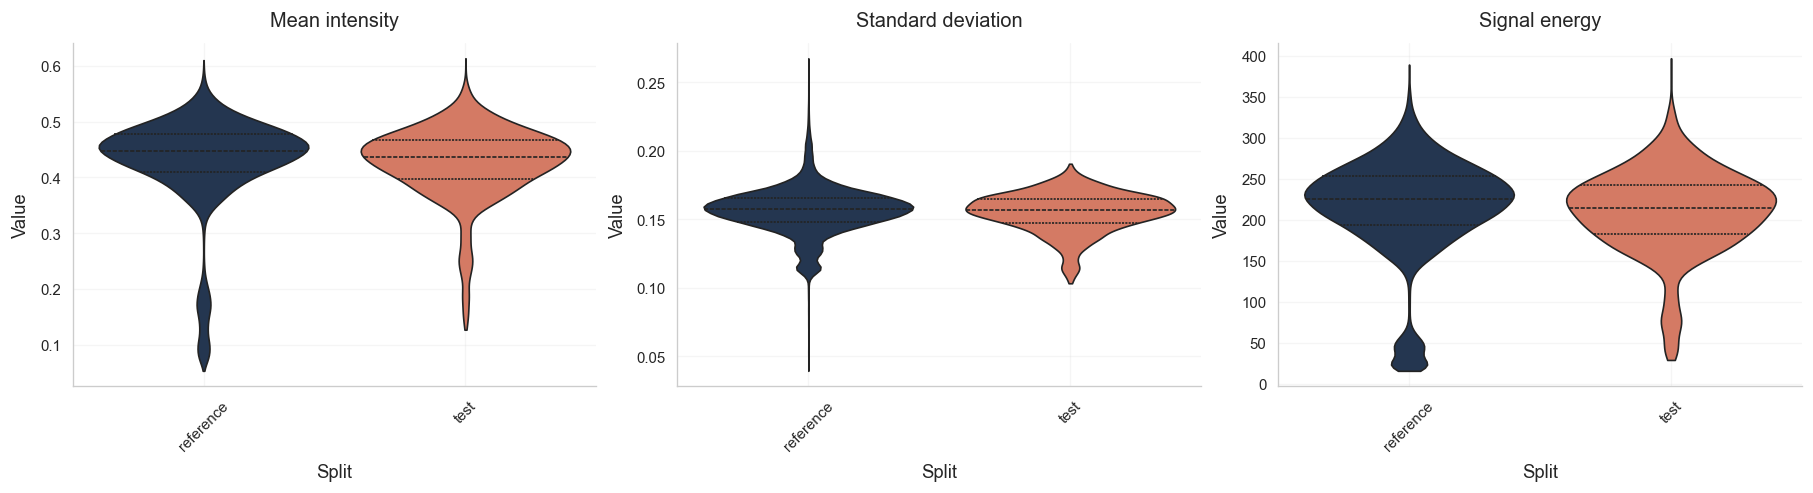

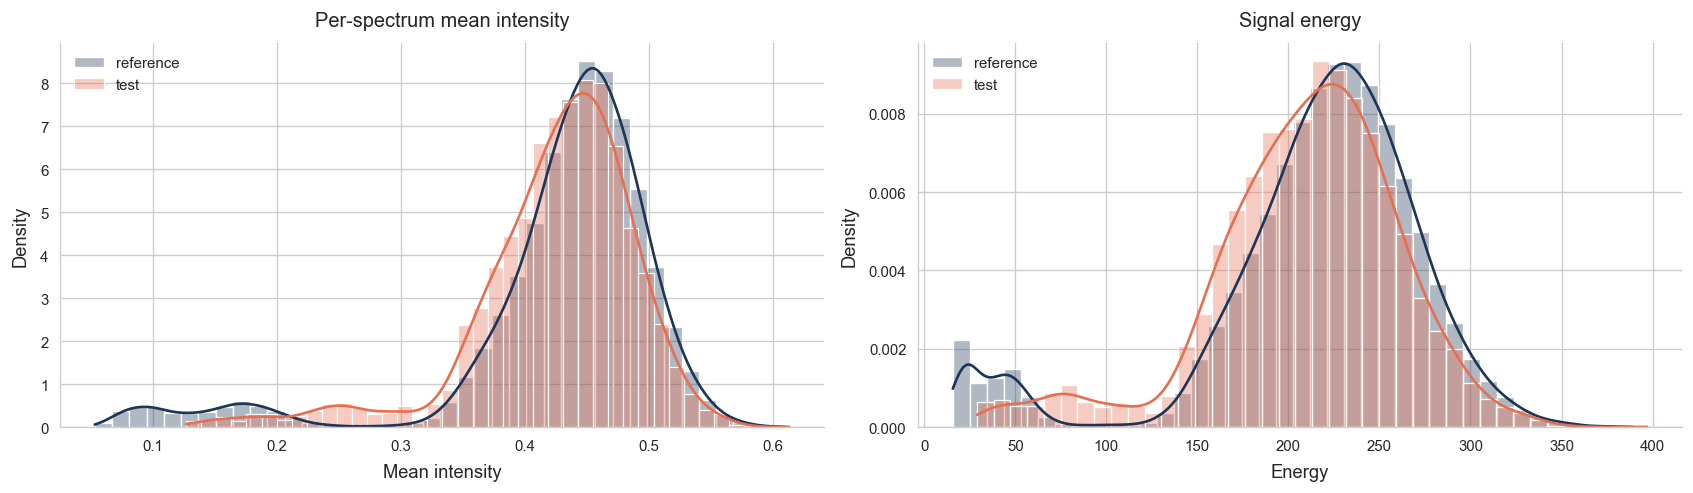

In [20]:
global_stats_df = pd.DataFrame([
    summarize_split("reference", reference),
    summarize_split("test", test),
])
display(global_stats_df)

summary_long = []
for split_name, split_data in [("reference", reference), ("test", test)]:
    X = split_data["X"]
    summary_long.append(pd.DataFrame({
        "split": split_name,
        "metric": "mean intensity",
        "value": X.mean(axis=1),
    }))
    summary_long.append(pd.DataFrame({
        "split": split_name,
        "metric": "standard deviation",
        "value": X.std(axis=1),
    }))
    summary_long.append(pd.DataFrame({
        "split": split_name,
        "metric": "signal energy",
        "value": np.sum(X ** 2, axis=1),
    }))

summary_metrics_df = pd.concat(summary_long, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
metrics = ["mean intensity", "standard deviation", "signal energy"]
titles = ["Mean intensity", "Standard deviation", "Signal energy"]
for axis, metric, title in zip(axes, metrics, titles):
    subset = summary_metrics_df[summary_metrics_df["metric"] == metric]
    sns.violinplot(data=subset, x="split", y="value", hue="split", inner="quartile", cut=0, linewidth=1, palette=plot_colors, dodge=False, legend=False, ax=axis)
    style_axis(axis, title, "Split", "Value")
    axis.tick_params(axis="x", rotation=45)
    axis.grid(alpha=0.18)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
sns.histplot(reference["X"].mean(axis=1), bins=40, kde=True, color=plot_colors["reference"], stat="density", alpha=0.35, label="reference", ax=axes[0])
sns.histplot(test["X"].mean(axis=1), bins=40, kde=True, color=plot_colors["test"], stat="density", alpha=0.35, label="test", ax=axes[0])
style_axis(axes[0], "Per-spectrum mean intensity", "Mean intensity", "Density")
format_legend(axes[0], loc="upper left")

sns.histplot(np.sum(reference["X"] ** 2, axis=1), bins=40, kde=True, color=plot_colors["reference"], stat="density", alpha=0.35, label="reference", ax=axes[1])
sns.histplot(np.sum(test["X"] ** 2, axis=1), bins=40, kde=True, color=plot_colors["test"], stat="density", alpha=0.35, label="test", ax=axes[1])
style_axis(axes[1], "Signal energy", "Energy", "Density")
format_legend(axes[1], loc="upper left")
plt.show()

These plots separate coarse scale changes from broader distributional differences. Small shifts are still informative because they show how the two splits are arranged at a global statistical level.

## 3. Global Mean Spectrum Comparison

Compare the average Raman profiles directly. The mean spectrum summarizes morphology alignment across the shift axis, and the difference curve shows where the split averages diverge point by point.

,split,mean_intensity,std_intensity,l2_to_other_mean,mean_abs_diff_to_other_mean
0,reference,0.427644,0.180745,1.170949,0.029449
1,test,0.425135,0.169145,1.170949,0.029449


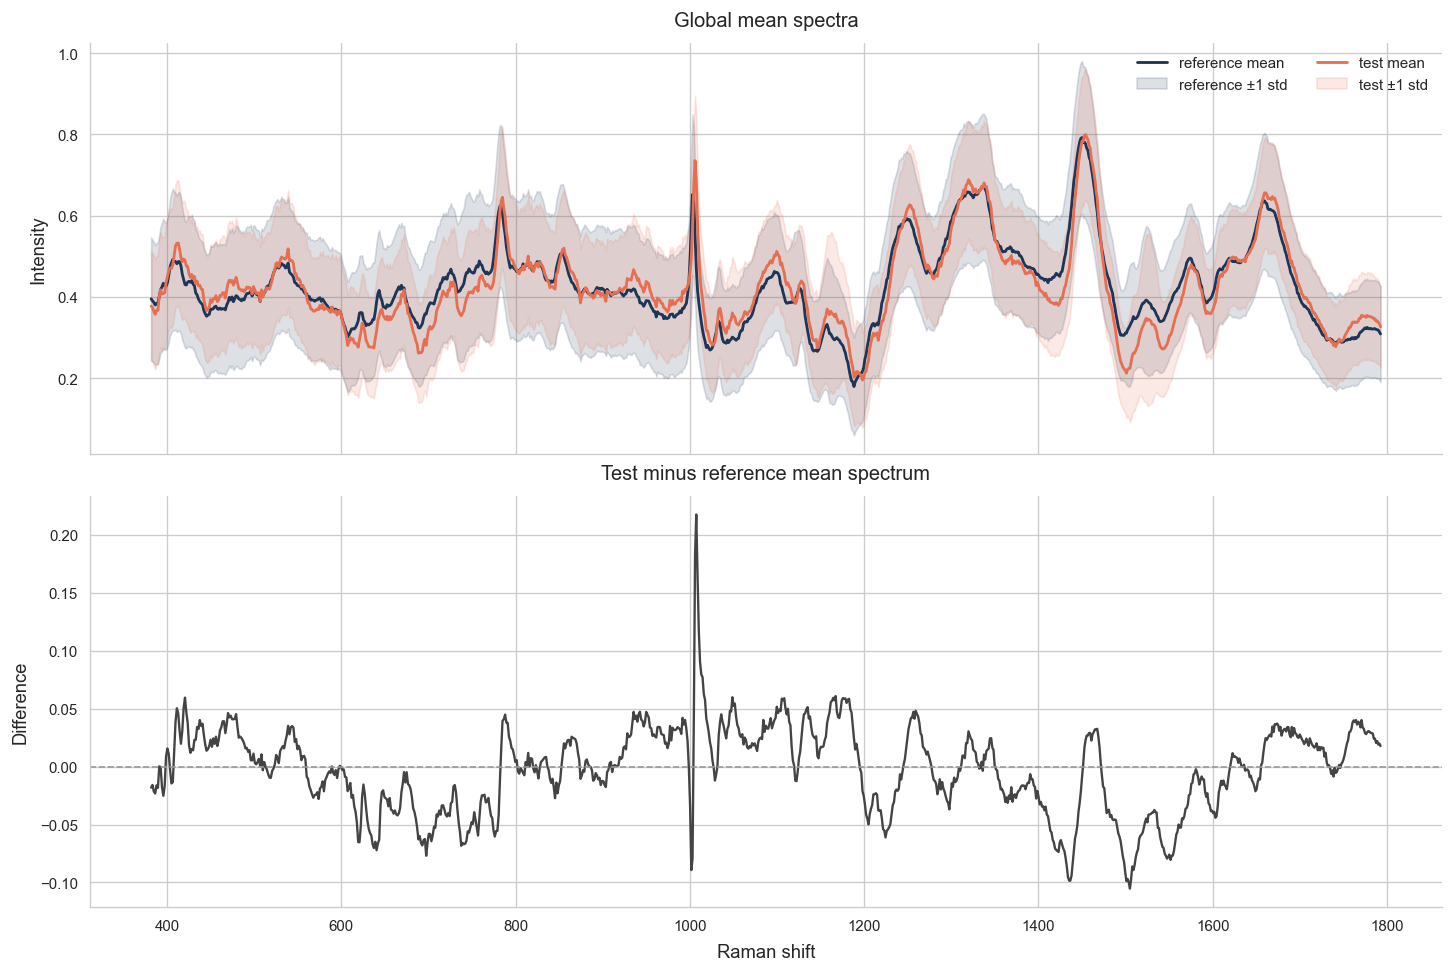

In [14]:
reference_mean = reference["X"].mean(axis=0)
test_mean = test["X"].mean(axis=0)
reference_std = reference["X"].std(axis=0)
test_std = test["X"].std(axis=0)
mean_difference = test_mean - reference_mean

mean_comparison_df = pd.DataFrame([{
    "split": "reference",
    "mean_intensity": float(reference["X"].mean()),
    "std_intensity": float(reference["X"].std()),
    "l2_to_other_mean": float(np.linalg.norm(mean_difference)),
    "mean_abs_diff_to_other_mean": float(np.mean(np.abs(mean_difference))),
}, {
    "split": "test",
    "mean_intensity": float(test["X"].mean()),
    "std_intensity": float(test["X"].std()),
    "l2_to_other_mean": float(np.linalg.norm(mean_difference)),
    "mean_abs_diff_to_other_mean": float(np.mean(np.abs(mean_difference))),
}])
display(mean_comparison_df)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
axes[0].plot(wavenumbers, reference_mean, color=plot_colors["reference"], linewidth=1.7, label="reference mean")
axes[0].fill_between(wavenumbers, reference_mean - reference_std, reference_mean + reference_std, color=plot_colors["reference"], alpha=0.15, label="reference ±1 std")
axes[0].plot(wavenumbers, test_mean, color=plot_colors["test"], linewidth=1.7, label="test mean")
axes[0].fill_between(wavenumbers, test_mean - test_std, test_mean + test_std, color=plot_colors["test"], alpha=0.15, label="test ±1 std")
style_axis(axes[0], "Global mean spectra", "", "Intensity")
format_legend(axes[0], loc="upper right", ncol=2)

axes[1].plot(wavenumbers, mean_difference, color="#444444", linewidth=1.4)
axes[1].axhline(0, color="#999999", linewidth=1, linestyle="--")
style_axis(axes[1], "Test minus reference mean spectrum", "Raman shift", "Difference")
axes[1].grid(alpha=0.18)
sns.despine(fig)
plt.show()

The mean spectra appear broadly similar, but the difference curve makes it easier to see where the two split averages separate. The next section places the combined spectra in a low-dimensional space for a global view.

## 4. PCA-Based Split Visualization

Project sampled spectra into a shared PCA space to obtain a coarse geometric view of morphology alignment. The aim is to see whether the two splits occupy the same broad cloud or show partially separated structure.

,split,pc1_centroid,pc2_centroid
0,reference,-0.023744,0.033793
1,test,0.023744,-0.033793


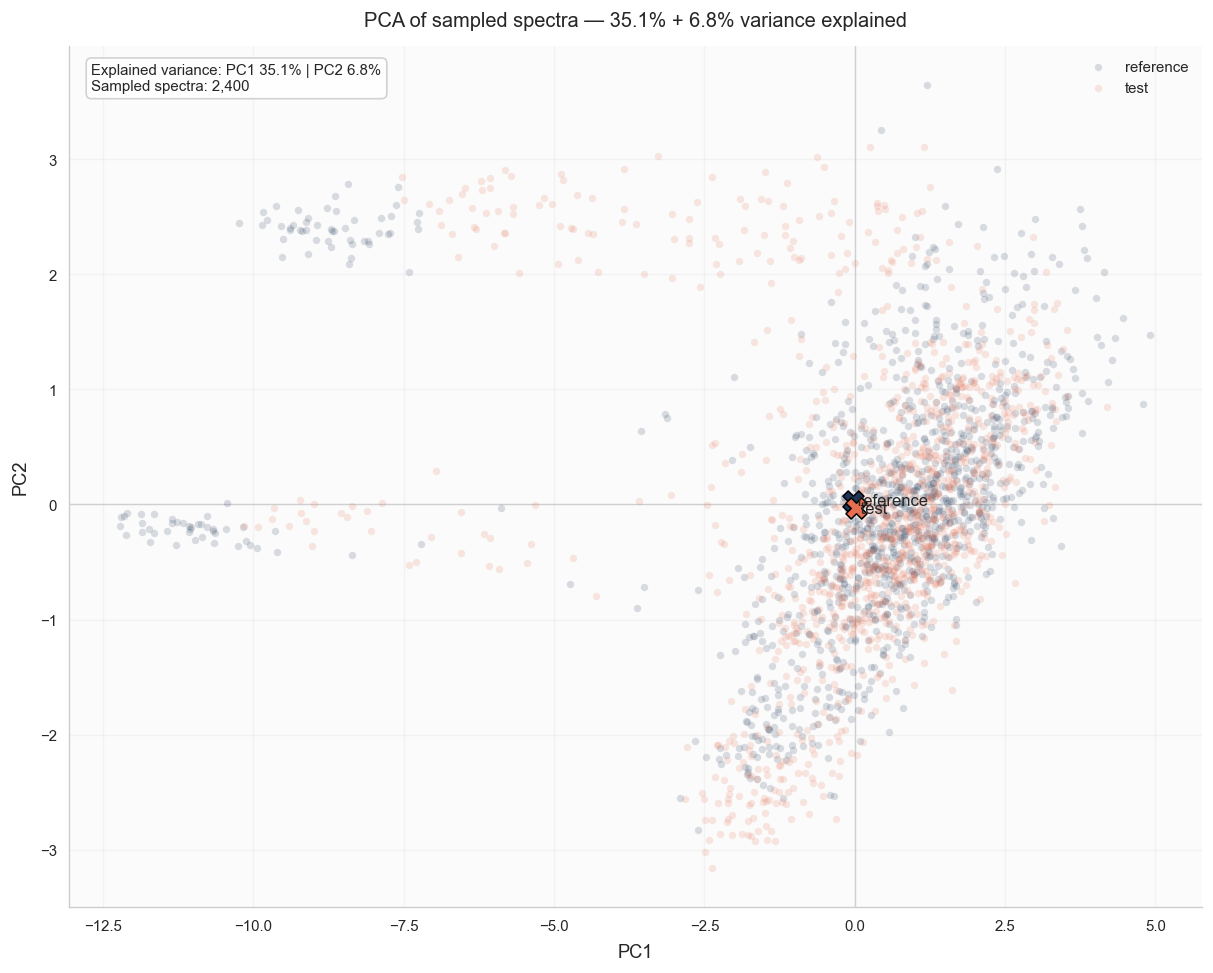

In [21]:
sample_size = min(1200, reference["X"].shape[0], test["X"].shape[0])
reference_indices = rng.choice(reference["X"].shape[0], size=sample_size, replace=False)
test_indices = rng.choice(test["X"].shape[0], size=sample_size, replace=False)
pca_input = np.vstack([reference["X"][reference_indices], test["X"][test_indices]])
pca_labels = np.array(["reference"] * sample_size + ["test"] * sample_size)
pca = PCA(n_components=2, random_state=19)
pca_coords = pca.fit_transform(pca_input)

pca_summary_df = pd.DataFrame([
    {
        "split": "reference",
        "pc1_centroid": float(pca_coords[pca_labels == "reference", 0].mean()),
        "pc2_centroid": float(pca_coords[pca_labels == "reference", 1].mean()),
    },
    {
        "split": "test",
        "pc1_centroid": float(pca_coords[pca_labels == "test", 0].mean()),
        "pc2_centroid": float(pca_coords[pca_labels == "test", 1].mean()),
    },
])
display(pca_summary_df)

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
for split_name in ["reference", "test"]:
    color = plot_colors[split_name]
    mask = pca_labels == split_name
    ax.scatter(
        pca_coords[mask, 0],
        pca_coords[mask, 1],
        s=20,
        alpha=0.16,
        color=color,
        label=split_name,
        linewidths=0,
        rasterized=True,
        zorder=1,
    )
    centroid = pca_coords[mask].mean(axis=0)
    ax.scatter(
        centroid[0],
        centroid[1],
        s=160,
        marker="X",
        color=color,
        edgecolors="black",
        linewidths=0.9,
        zorder=5,
    )
    ax.text(centroid[0], centroid[1], f" {split_name}", fontsize=10, va="center", ha="left", zorder=6)

ax.axhline(0, color="#d0d0d0", linewidth=0.8, zorder=0)
ax.axvline(0, color="#d0d0d0", linewidth=0.8, zorder=0)
ax.set_facecolor("#fbfbfb")
style_axis(ax, "PCA of sampled spectra", "PC1", "PC2")
ax.set_title(
    f"PCA of sampled spectra — {pca.explained_variance_ratio_[0]:.1%} + {pca.explained_variance_ratio_[1]:.1%} variance explained",
    pad=12,
)
add_variance_annotation(ax, pca, pca_input.shape[0])
format_legend(ax, loc="upper right")
ax.grid(alpha=0.18)
sns.despine(ax=ax)
plt.show()

The PCA view is intended as a coarse geometric check on overlap and separation. It shows whether the splits share a similar spectral cloud while remaining descriptive rather than interpretive.

## 5. Class-Wise Split Comparison

Compare the reference and test mean spectra within each class and rank the classes by drift magnitude. This shows whether the split difference is broadly uniform or concentrated in a subset of classes.

class_label,reference_count,test_count,cosine_similarity,euclidean_distance,mean_abs_deviation,max_abs_deviation
1,2000,100,0.947,4.638,0.1171,0.3896
13,2000,100,0.962,4.236,0.1104,0.3498
27,2000,100,0.893,3.994,0.1191,0.2701
21,2000,100,0.971,3.983,0.1096,0.2779
18,2000,100,0.961,3.497,0.1032,0.2703
16,2000,100,0.988,3.073,0.0861,0.2834
29,2000,100,0.988,2.549,0.0635,0.2870
12,2000,100,0.990,2.227,0.0595,0.2933
2,2000,100,0.991,2.179,0.0530,0.2703
3,2000,100,0.991,2.103,0.0537,0.3296


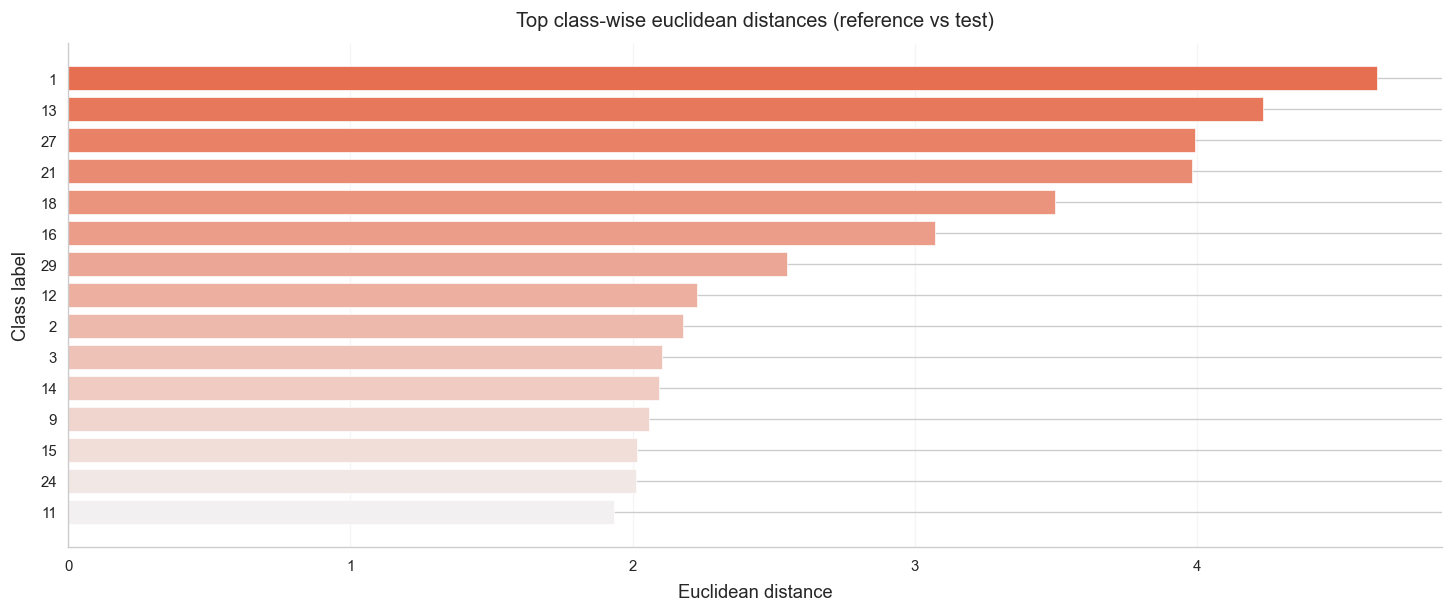

In [22]:
class_rows = []
for class_id in range(30):
    ref_class = reference["X"][reference["y"] == class_id]
    test_class = test["X"][test["y"] == class_id]

    ref_mean = ref_class.mean(axis=0)
    test_mean = test_class.mean(axis=0)
    diff = ref_mean - test_mean
    ref_norm = np.linalg.norm(ref_mean)
    test_norm = np.linalg.norm(test_mean)
    cosine_similarity = float(np.dot(ref_mean, test_mean) / (ref_norm * test_norm))

    class_rows.append({
        "class_label": class_id,
        "reference_count": int(ref_class.shape[0]),
        "test_count": int(test_class.shape[0]),
        "cosine_similarity": cosine_similarity,
        "euclidean_distance": float(np.linalg.norm(diff)),
        "mean_abs_deviation": float(np.mean(np.abs(diff))),
        "max_abs_deviation": float(np.max(np.abs(diff))),
    })

class_drift_df = pd.DataFrame(class_rows).sort_values("euclidean_distance", ascending=False).reset_index(drop=True)

# Tidy table for display: round and format consistently
class_table_df = class_drift_df.head(12).copy()
class_table_df_display = (
    class_table_df.style
    .format(
        {
            "cosine_similarity": "{:.3f}",
            "euclidean_distance": "{:.3f}",
            "mean_abs_deviation": "{:.4f}",
            "max_abs_deviation": "{:.4f}",
        }
    )
    .background_gradient(subset=["euclidean_distance"], cmap="YlOrRd")
    .hide(axis="index")
)

display(class_table_df_display)

# Bar plot for top classes
plot_df = class_drift_df.head(15).iloc[::-1].copy()
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
colors = sns.light_palette(plot_colors["test"], n_colors=len(plot_df))
ax.barh(plot_df["class_label"].astype(str), plot_df["euclidean_distance"], color=colors, edgecolor="white", linewidth=0.4)
style_axis(ax, "Top class-wise euclidean distances (reference vs test)", "Euclidean distance", "Class label")
ax.grid(axis="x", alpha=0.18)
sns.despine(ax=ax, left=False, bottom=False)
plt.show()

Certain classes exhibit larger split-level spectral deviation than others. The ranking below is intentionally descriptive: it helps identify where the strongest class-wise differences occur without assigning any later-stage interpretation.

## 6. Split-Level Distribution Metrics

Raw centroid distance and cosine similarity summarize average morphology alignment, while PCA covariance summarizes how spread and variability are organized within each split.

,reference,test,comparison
metric,,,
centroid distance (raw),1.1709,1.1709,reference vs test
centroid cosine similarity (raw),0.9964,0.9964,reference vs test
mean abs centroid diff (raw),0.0294,0.0294,reference vs test
mean within-split variance,0.0223,0.0173,within-split variance


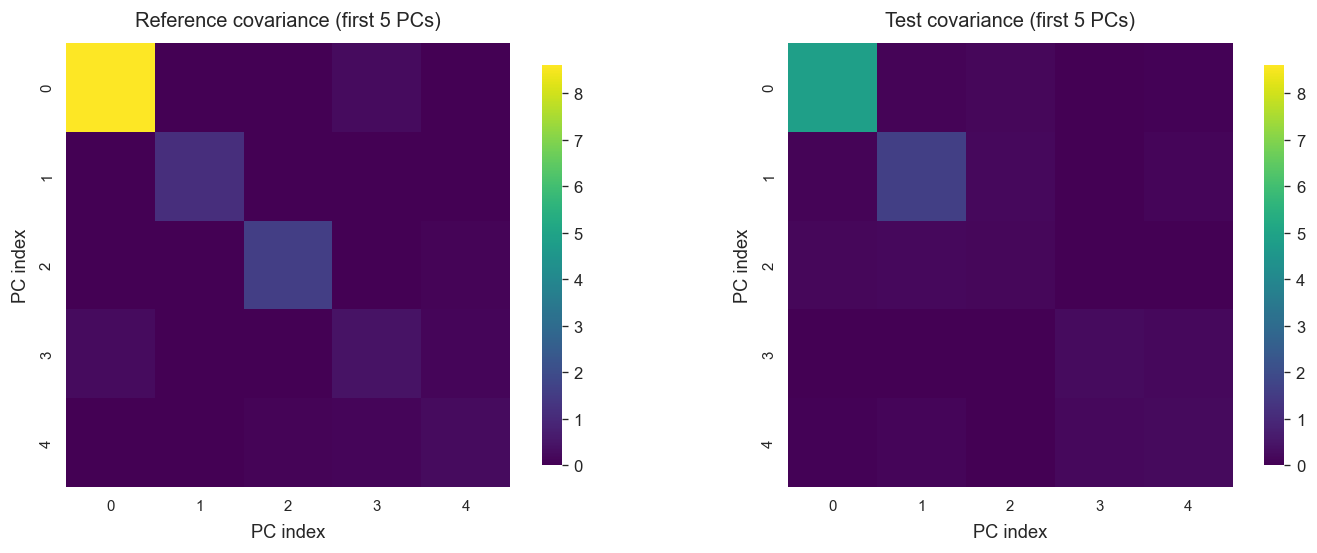

In [23]:
combined_sample_size = 1500
ref_idx = rng.choice(reference["X"].shape[0], size=combined_sample_size, replace=False)
test_idx = rng.choice(test["X"].shape[0], size=combined_sample_size, replace=False)
combined = np.vstack([reference["X"][ref_idx], test["X"][test_idx]])
combined_labels = np.array(["reference"] * combined_sample_size + ["test"] * combined_sample_size)
combined_pca = PCA(n_components=5, random_state=19)
combined_scores = combined_pca.fit_transform(combined)

ref_scores = combined_scores[combined_labels == "reference"]
test_scores = combined_scores[combined_labels == "test"]
ref_centroid = ref_scores.mean(axis=0)
test_centroid = test_scores.mean(axis=0)

reference_mean_raw = reference["X"].mean(axis=0)
test_mean_raw = test["X"].mean(axis=0)
raw_centroid_distance = float(np.linalg.norm(reference_mean_raw - test_mean_raw))
raw_centroid_similarity = float(np.dot(reference_mean_raw, test_mean_raw) / (np.linalg.norm(reference_mean_raw) * np.linalg.norm(test_mean_raw)))
raw_centroid_mad = float(np.mean(np.abs(reference_mean_raw - test_mean_raw)))

distribution_metrics_df = pd.DataFrame([
    {
        "metric": "centroid_distance_raw",
        "reference": raw_centroid_distance,
        "test": raw_centroid_distance,
        "comparison": "reference vs test",
    },
    {
        "metric": "centroid_cosine_similarity_raw",
        "reference": raw_centroid_similarity,
        "test": raw_centroid_similarity,
        "comparison": "reference vs test",
    },
    {
        "metric": "mean_abs_centroid_diff_raw",
        "reference": raw_centroid_mad,
        "test": raw_centroid_mad,
        "comparison": "reference vs test",
    },
    {
        "metric": "mean_within_split_variance",
        "reference": float(reference["X"].var(axis=0).mean()),
        "test": float(test["X"].var(axis=0).mean()),
        "comparison": "within-split variance",
    },
])

# Friendly display: concise metric names and consistent precision
display(
    distribution_metrics_df.assign(
        reference=lambda df: df["reference"].round(4),
        test=lambda df: df["test"].round(4),
        metric=lambda df: df["metric"].replace({
            "centroid_distance_raw": "centroid distance (raw)",
            "centroid_cosine_similarity_raw": "centroid cosine similarity (raw)",
            "mean_abs_centroid_diff_raw": "mean abs centroid diff (raw)",
            "mean_within_split_variance": "mean within-split variance",
        })
    ).set_index("metric")
)

# Covariance heatmaps (first 5 PCs) — use common color scaling for comparability
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
ref_cov = np.cov(ref_scores, rowvar=False)
test_cov = np.cov(test_scores, rowvar=False)
vmax = max(ref_cov.max(), test_cov.max())

sns.heatmap(ref_cov, cmap="viridis", square=True, ax=axes[0], cbar_kws={"shrink": 0.9}, vmin=0, vmax=vmax)
style_axis(axes[0], "Reference covariance (first 5 PCs)", "PC index", "PC index")

sns.heatmap(test_cov, cmap="viridis", square=True, ax=axes[1], cbar_kws={"shrink": 0.9}, vmin=0, vmax=vmax)
style_axis(axes[1], "Test covariance (first 5 PCs)", "PC index", "PC index")
plt.show()

The PCA covariance summaries provide a global view of how the spectral clouds are organized within each split. The next section illustrates what class-level differences look like in representative overlays.

## 7. Representative Morphology Comparison

Select classes that span the observed drift range so the overlays remain balanced and illustrative. The purpose is to see how split-level morphology variation appears, not to isolate unusual behavior.

class_label,euclidean_distance,cosine_similarity,reference_count,test_count
1,4.638,0.9474,2000,100
29,2.549,0.9878,2000,100
15,2.017,0.9921,2000,100
28,1.854,0.9924,2000,100
0,1.490,0.9943,2000,100
19,0.997,0.9978,2000,100


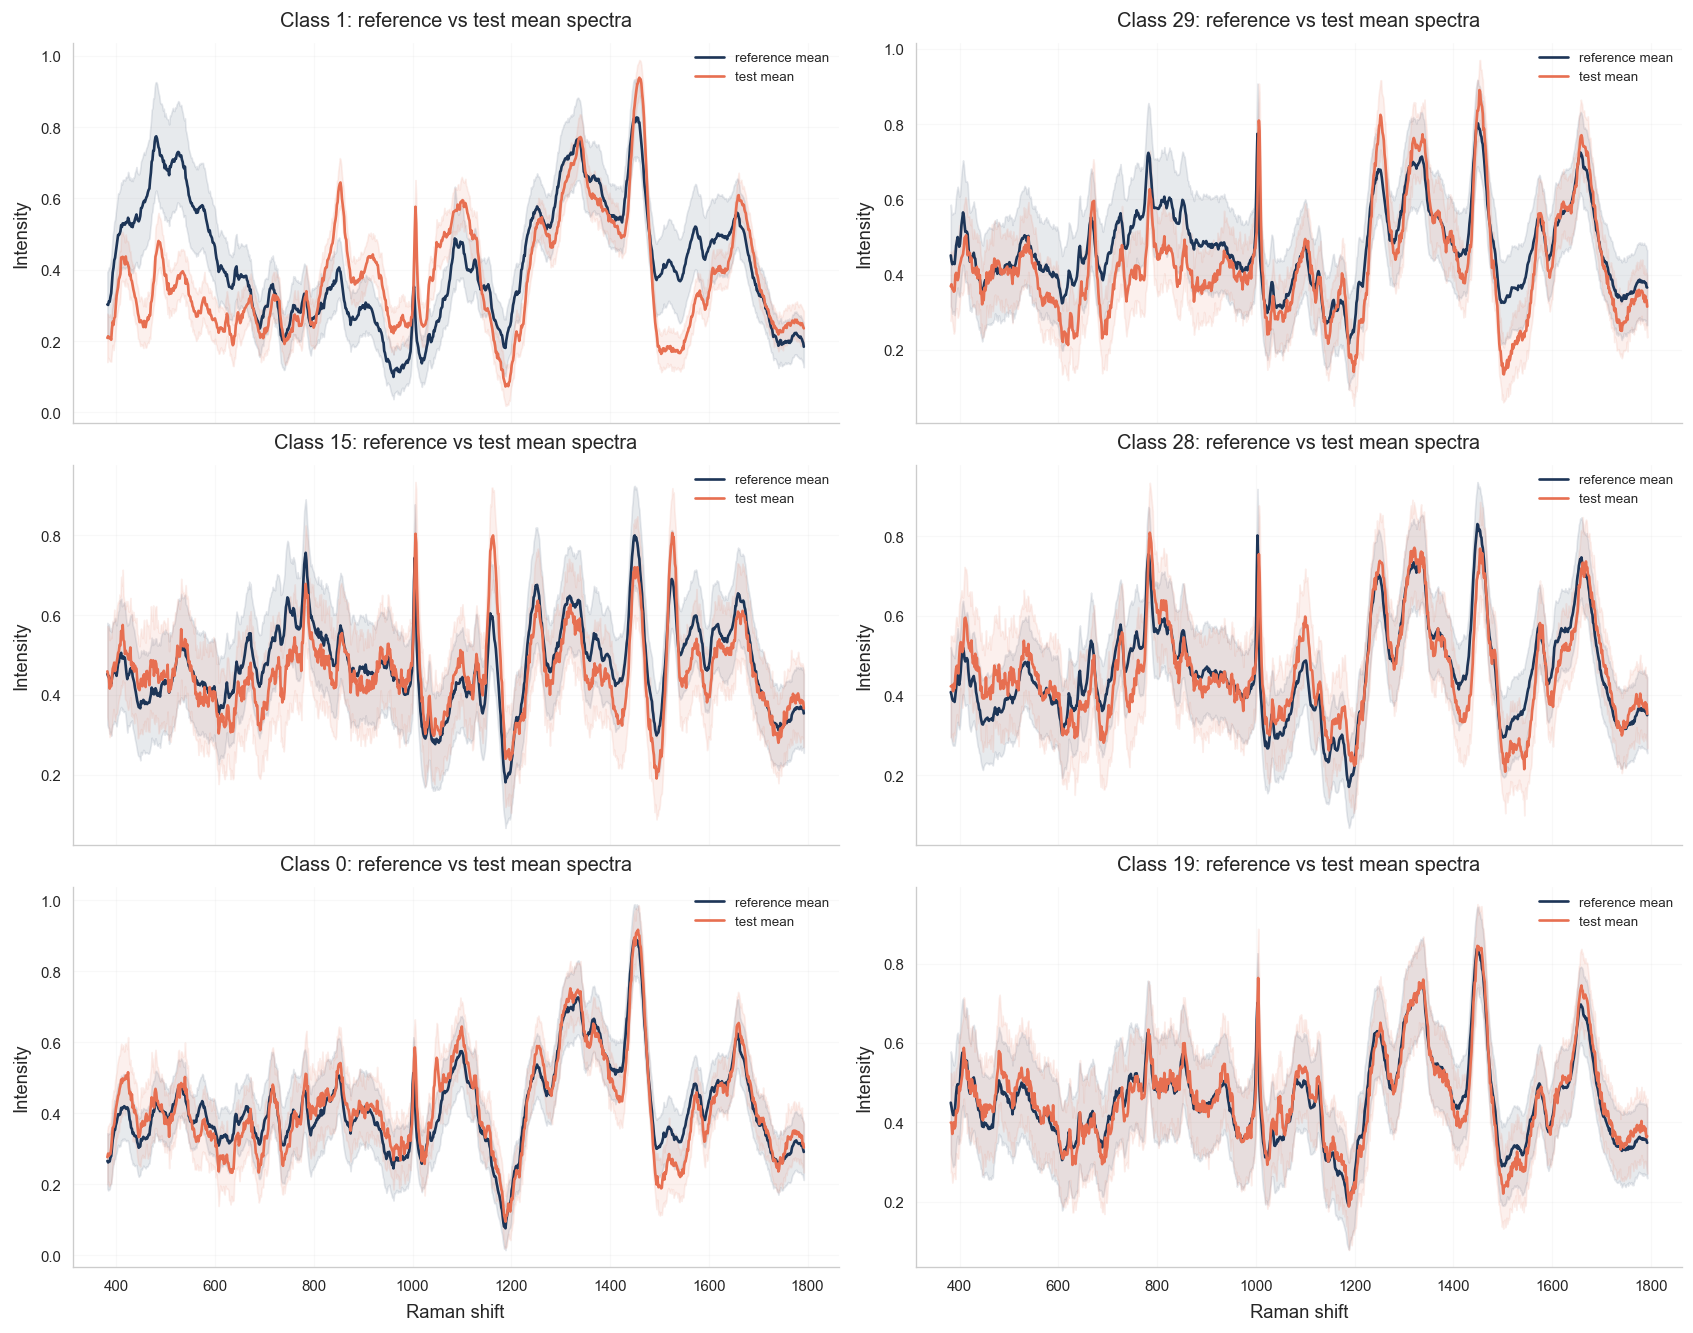

In [18]:
rank_positions = np.linspace(0, len(class_drift_df) - 1, 6).round().astype(int)
selected_classes = class_drift_df.iloc[rank_positions]["class_label"].astype(int).tolist()
selected_class_summary = class_drift_df[class_drift_df["class_label"].isin(selected_classes)][
    ["class_label", "euclidean_distance", "cosine_similarity", "reference_count", "test_count"]
].sort_values("euclidean_distance", ascending=False)

display(
    selected_class_summary.style.format(
        {
            "euclidean_distance": "{:.3f}",
            "cosine_similarity": "{:.4f}",
        }
    ).hide(axis="index")
)

fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True, constrained_layout=True)
axes = axes.ravel()
for axis, class_id in zip(axes, selected_classes):
    ref_class = reference["X"][reference["y"] == class_id]
    test_class = test["X"][test["y"] == class_id]
    ref_mean = ref_class.mean(axis=0)
    test_mean = test_class.mean(axis=0)
    ref_std = ref_class.std(axis=0)
    test_std = test_class.std(axis=0)

    axis.plot(wavenumbers, ref_mean, color=plot_colors["reference"], linewidth=1.6, label="reference mean")
    axis.fill_between(wavenumbers, ref_mean - ref_std, ref_mean + ref_std, color=plot_colors["reference"], alpha=0.10)
    axis.plot(wavenumbers, test_mean, color=plot_colors["test"], linewidth=1.6, label="test mean")
    axis.fill_between(wavenumbers, test_mean - test_std, test_mean + test_std, color=plot_colors["test"], alpha=0.10)
    style_axis(axis, f"Class {class_id}: reference vs test mean spectra", "", "Intensity")
    axis.legend(frameon=False, loc="upper right", fontsize=8, handlelength=2.2, borderaxespad=0.3)
    axis.grid(alpha=0.12)

for axis in axes[len(selected_classes):]:
    axis.axis("off")

for axis in axes[-2:]:
    axis.set_xlabel("Raman shift")

sns.despine(fig)
plt.show()

The overlays show that split-level morphology variation is visible in a few classes and subtle in others. That pattern is consistent with the class-wise ranking above and remains a descriptive observation.

## 8. Summary Observations

The reference and test splits are broadly similar but not identical across multiple perspectives: global summary statistics, mean spectra, PCA geometry, and class-wise comparisons. Representative overlays show that some classes display larger split-level morphology variation while others remain similar in shape.

The analyses suggest that the holdout split is not perfectly identical to the reference split in terms of statistical and spectral characteristics.